In [ ]:
import csv
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

bible_files = sorted(Path("../../../data/0_raw").glob("*_bible.csv"))
totals = {}
for f in bible_files:
    total = 0
    with open(f, encoding="utf-8") as fh:
        r = csv.DictReader(fh)
        for row in r:
            total += int(row["frequency"])
    totals[f.stem.replace("_bible", "")] = total

codes = list(totals.keys())
freqs = list(totals.values())
print(f"Bible files: {len(codes)}")
print(f"Min: {min(freqs):,}  Max: {max(freqs):,}  Mean: {np.mean(freqs):,.0f}")

Bible files: 67
Min: 15,505  Max: 978,523  Mean: 503,434


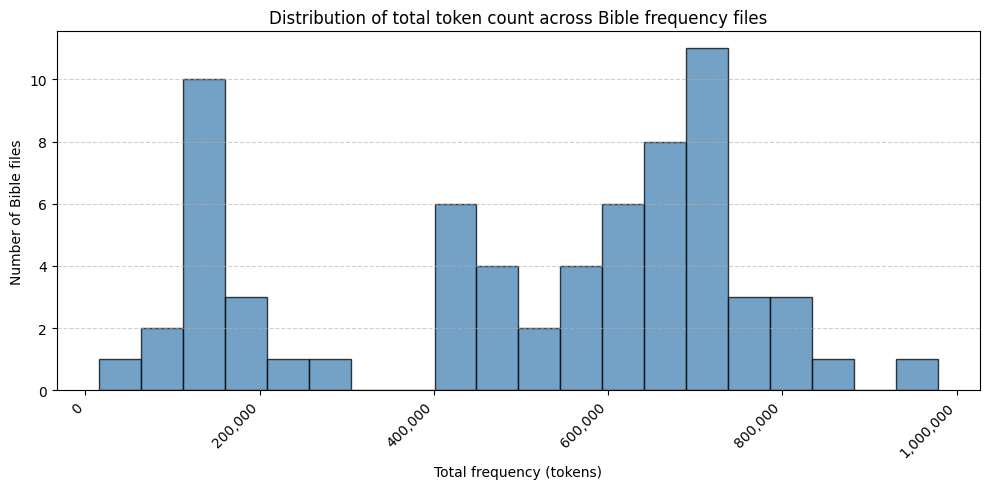

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(freqs, bins=20, edgecolor="black", alpha=0.75, color="steelblue")
ax.set_xlabel("Total frequency (tokens)")
ax.set_ylabel("Number of Bible files")
ax.set_title("Distribution of total token count across Bible frequency files")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="y", linestyle="--", alpha=0.6)
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()